In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
from scipy.linalg import svdvals
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import pairwise_distances_argmin_min
from sklearn.metrics.pairwise import rbf_kernel
import os
import json
from scipy.linalg import cho_factor, cho_solve

**Load training data for all 7 joints seperately**

In [3]:
# Load CSV
io_data = pd.read_csv("tau_log_train.csv")

# Select columns by substring
u_full = io_data.filter(like="tau_cmd_").to_numpy() # shape (T, 7)
y_full = io_data.filter(like="tau_ext_").to_numpy() # shape (T, 7)

# Align so that u[k] corresponds to y[k+1]
u_data = u_full[:-1, :] # shape (T-1, 7)
y_data = y_full[1:, :] # shape (T-1, 7)

print(u_data.shape, y_data.shape)

# Seperate data per joint
per_joint_data = {}

for j in range(7):
    u_j = u_data[:, j].copy()   # shape (T,)
    y_j = y_data[:, j].copy()   # shape (T,)
    
    per_joint_data[j] = {
        "u": u_j,
        "y": y_j,
    }
    
    print(f"Joint {j}: u.shape={u_j.shape}, y.shape={y_j.shape}")

# print(per_joint_data.keys())



(29411, 7) (29411, 7)
Joint 0: u.shape=(29411,), y.shape=(29411,)
Joint 1: u.shape=(29411,), y.shape=(29411,)
Joint 2: u.shape=(29411,), y.shape=(29411,)
Joint 3: u.shape=(29411,), y.shape=(29411,)
Joint 4: u.shape=(29411,), y.shape=(29411,)
Joint 5: u.shape=(29411,), y.shape=(29411,)
Joint 6: u.shape=(29411,), y.shape=(29411,)


**Build Hankel matrices for all 7 joints**

In [4]:
m = 1  # input dimension (per joint)
p = 1  # output dimension (per joint)

T_past = 20
T_future = 10
L = T_past + T_future

N = u_data.shape[0]
cols = N - L + 1  # number of Hankel columns

def build_hankel_for_joint(u_j: np.ndarray,
                           y_j: np.ndarray,
                           T_past: int,
                           T_future: int):
    """
    u_j, y_j: 1D arrays of length N for a single joint.
    Returns Hu_past, Hu_future, Hy_past, Hy_future for that joint.
    """
    L = T_past + T_future
    cols = N - L + 1

    # Build full Hankel matrices Hu, Hy (m*L x cols), (p*L x cols)
    Hu_list = []
    Hy_list = []
    for i in range(cols):
        Hu_list.append(u_j[i:i+L].reshape(m*L, 1))
        Hy_list.append(y_j[i:i+L].reshape(p*L, 1))

    Hu = np.hstack(Hu_list)  # shape (m*L, cols)
    Hy = np.hstack(Hy_list)  # shape (p*L, cols)

    # Split into past and future
    Hu_past = Hu[:m*T_past, :] # shape (m*T_past, cols)
    Hu_future = Hu[-m*T_future:, :] # shape (m*T_future, cols)
    Hy_past = Hy[:p*T_past, :] # shape (p*T_past, cols)
    Hy_future = Hy[-p*T_future:, :] # shape (p*T_future, cols)

    return Hu_past, Hu_future, Hy_past, Hy_future

# Build Hankel matrices per joint
hankel_per_joint = {}

for j in range(7):
    u_j = u_data[:, j]
    y_j = y_data[:, j]

    Hu_past_j, Hu_future_j, Hy_past_j, Hy_future_j = build_hankel_for_joint(
        u_j, y_j, T_past, T_future
    )

    hankel_per_joint[j] = {
        "Hu_past": Hu_past_j,
        "Hu_future": Hu_future_j,
        "Hy_past": Hy_past_j,
        "Hy_future": Hy_future_j,
    }

    print(f"Joint {j}: Hu_past {Hu_past_j.shape}, Hu_future {Hu_future_j.shape}, "
          f"Hy_past {Hy_past_j.shape}, Hy_future {Hy_future_j.shape}")


Joint 0: Hu_past (20, 29382), Hu_future (10, 29382), Hy_past (20, 29382), Hy_future (10, 29382)
Joint 1: Hu_past (20, 29382), Hu_future (10, 29382), Hy_past (20, 29382), Hy_future (10, 29382)
Joint 2: Hu_past (20, 29382), Hu_future (10, 29382), Hy_past (20, 29382), Hy_future (10, 29382)
Joint 3: Hu_past (20, 29382), Hu_future (10, 29382), Hy_past (20, 29382), Hy_future (10, 29382)
Joint 4: Hu_past (20, 29382), Hu_future (10, 29382), Hy_past (20, 29382), Hy_future (10, 29382)
Joint 5: Hu_past (20, 29382), Hu_future (10, 29382), Hy_past (20, 29382), Hy_future (10, 29382)
Joint 6: Hu_past (20, 29382), Hu_future (10, 29382), Hy_past (20, 29382), Hy_future (10, 29382)


**Plot SVD for all 7 joints**

Joint 0: H shape = (60, 29382), rank = 60
Joint 1: H shape = (60, 29382), rank = 60
Joint 2: H shape = (60, 29382), rank = 60
Joint 3: H shape = (60, 29382), rank = 60
Joint 4: H shape = (60, 29382), rank = 60
Joint 5: H shape = (60, 29382), rank = 60
Joint 6: H shape = (60, 29382), rank = 60


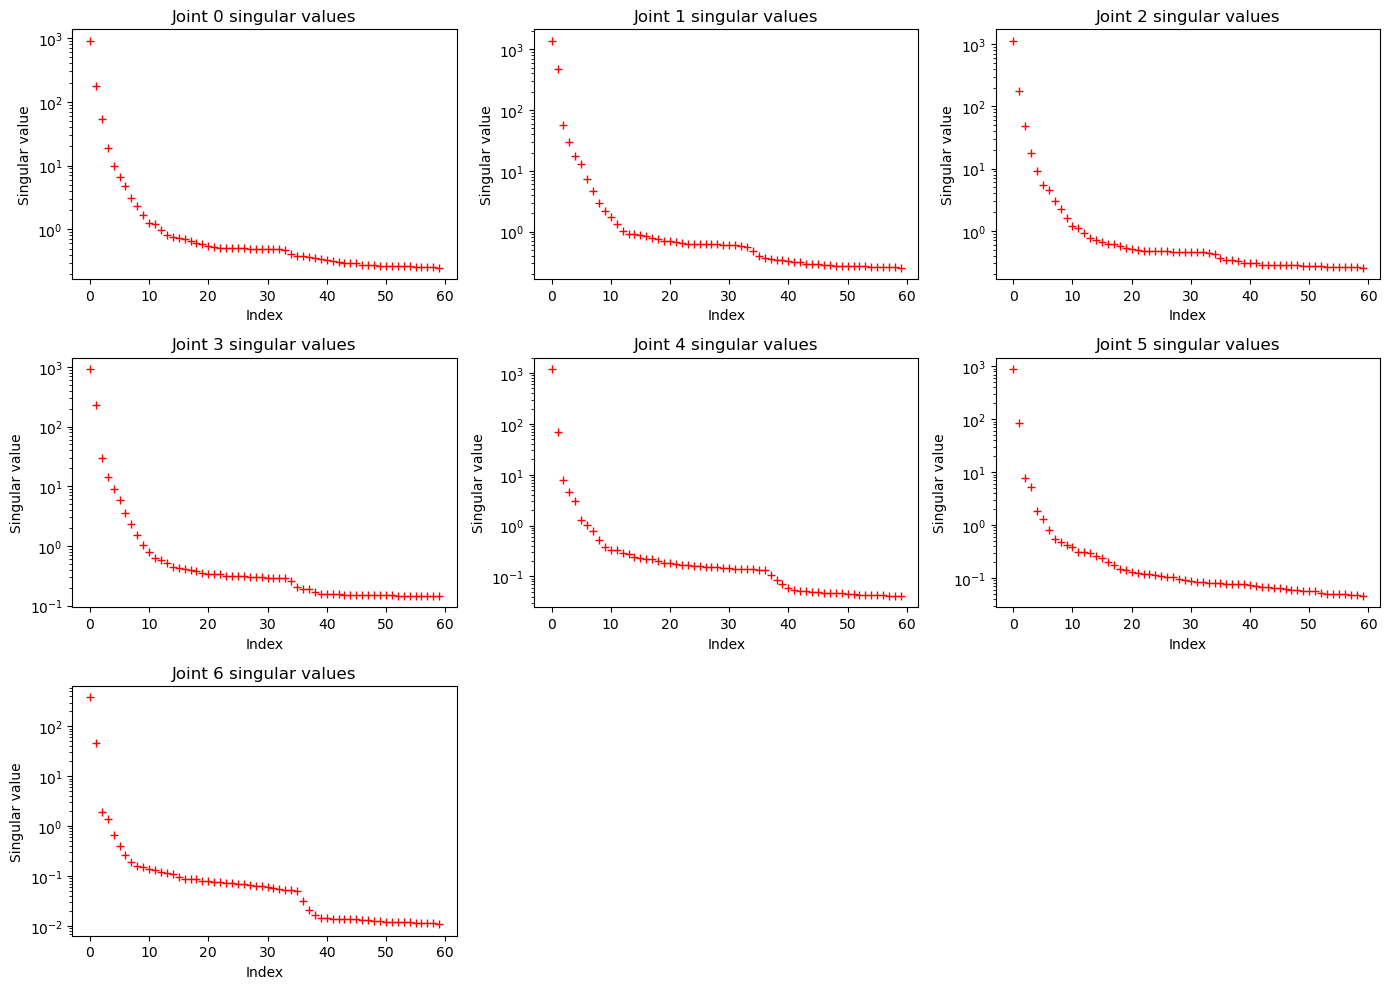

In [5]:
plt.figure(figsize=(14, 10))

for j in range(7):
    Hu_past = hankel_per_joint[j]["Hu_past"]
    Hu_future = hankel_per_joint[j]["Hu_future"]
    Hy_past = hankel_per_joint[j]["Hy_past"]
    Hy_future = hankel_per_joint[j]["Hy_future"]

    # Full Hankel matrix H = [Hu; Hy]
    Hu = np.vstack((Hu_past, Hu_future))
    Hy = np.vstack((Hy_past, Hy_future))
    H = np.vstack((Hu, Hy))   # shape = ((m+p)*L , cols)

    # Compute singular values
    svals = svdvals(H)

    # Plot
    plt.subplot(3, 3, j+1)
    plt.semilogy(svals, 'r+')
    plt.title(f'Joint {j} singular values')
    plt.xlabel('Index')
    plt.ylabel('Singular value')

    # Print matrix rank
    rank_H = np.linalg.matrix_rank(H, tol=1e-8)
    print(f"Joint {j}: H shape = {H.shape}, rank = {rank_H}")

plt.tight_layout()
plt.show()

**Subsample all Hankel matrices**

In [6]:
m_clusters = 100  # desired number of representative columns

def subsample_hankel(Hu_past, Hy_past, Hu_future, m_clusters=100):
    """
    Subsample columns of the Hankel matrices using K-means clustering.

    Returns:
        Hu_past_sub, Hy_past_sub, Hu_future_sub, Hy_future_sub, X_sub, S
    """
    # Full Hankel matrix X = [Hu_past; Hy_past; Hu_future]
    X = np.vstack((Hu_past, Hy_past, Hu_future)) # shape (d, Hc)
    X_samples = X.T # shape (Hc, d)

    Hc = X_samples.shape[0]
    n_clusters = min(m_clusters, Hc) # cannot have more clusters than samples

    kmeans = MiniBatchKMeans(
        n_clusters=n_clusters,
        batch_size=4096,
        max_iter=200,
        n_init="auto",
        random_state=0,
        verbose=0,
    )
    kmeans.fit(X_samples)

    centers = kmeans.cluster_centers_
    nearest_idx, _ = pairwise_distances_argmin_min(centers, X_samples)

    S = np.sort(nearest_idx) # sorted indices of chosen columns

    Hu_past_sub = Hu_past[:, S]
    Hy_past_sub = Hy_past[:, S]
    Hu_future_sub = Hu_future[:, S]
    Hy_future_sub = Hy_future[:, S]

    X_sub = np.vstack((Hu_past_sub, Hy_past_sub, Hu_future_sub)) # (d, Hc_sub)

    return Hu_past_sub, Hy_past_sub, Hu_future_sub, Hy_future_sub, X_sub, S

# Subsample all 7 joints
subsampled_per_joint = {}

for j in range(7):
    Hu_past = hankel_per_joint[j]["Hu_past"]
    Hu_future = hankel_per_joint[j]["Hu_future"]
    Hy_past = hankel_per_joint[j]["Hy_past"]
    Hy_future = hankel_per_joint[j]["Hy_future"]

    Hu_past_sub, Hy_past_sub, Hu_future_sub, Hy_future_sub, X_sub, S = subsample_hankel(
        Hu_past, Hy_past, Hu_future, m_clusters=m_clusters
    )

    subsampled_per_joint[j] = {
        "Hu_past_sub": Hu_past_sub,
        "Hy_past_sub": Hy_past_sub,
        "Hu_future_sub": Hu_future_sub,
        "Hy_future_sub": Hy_future_sub,
        "X_sub": X_sub,
        "indices": S,
    }

    print(f"Joint {j}: original cols={Hu_past.shape[1]}, subsampled cols={Hu_past_sub.shape[1]}")


Joint 0: original cols=29382, subsampled cols=100
Joint 1: original cols=29382, subsampled cols=100
Joint 2: original cols=29382, subsampled cols=100
Joint 3: original cols=29382, subsampled cols=100
Joint 4: original cols=29382, subsampled cols=100
Joint 5: original cols=29382, subsampled cols=100
Joint 6: original cols=29382, subsampled cols=100


**Load validation data**

In [7]:
# Load data
valid_data = pd.read_csv("tau_log_validation.csv")

# build arrays (first column is just 0.0)
u_data_valid_full = valid_data.filter(like="tau_cmd_").to_numpy() # remove last column to align with y
y_data_valid_full = valid_data.filter(like="tau_ext_").to_numpy() # remove first column to align with u

u_data_valid_full = u_data_valid_full[:-1, :] # shape (T-1, 7)
y_data_valid_full = y_data_valid_full[1:, :] # shape (T-1, 7)

print("u_data_valid_full shape:", u_data_valid_full.shape)
print("y_data_valid_full shape:", y_data_valid_full.shape)

u_data_valid_full shape: (56987, 7)
y_data_valid_full shape: (56987, 7)


**Build Kernel Gram matrix for all 7 joints**

In [8]:
best_gamma_rbf = 1e-3 # kernel length scale
gamma_reg = 1e-3 # gamma for Kg = K + gamma I
lambda_g = 1e1
lambda_k = 1e7

kernel_per_joint = {}

for j in range(7):

    # Extract subsampled Hankel blocks
    X_sub = subsampled_per_joint[j]["X_sub"]
    Hc_sub = X_sub.shape[1]

    X_samples = X_sub.T # shape (Hc_sub, d)

    # Build RBF Gram Matrix
    K = rbf_kernel(X_samples, X_samples, gamma=best_gamma_rbf)
    print("K shape:", K.shape)

    # Regularized Gram matrix
    Kg = K + gamma_reg * np.eye(Hc_sub)
    print("Kg shape:", Kg.shape)

    # Store everything needed for the next stages
    kernel_per_joint[j] = {
        "K": K,
        "Kg": Kg,
        "X_sub": X_sub,
        "Hu_past_sub":   subsampled_per_joint[j]["Hu_past_sub"],
        "Hy_past_sub":   subsampled_per_joint[j]["Hy_past_sub"],
        "Hu_future_sub": subsampled_per_joint[j]["Hu_future_sub"],
        "Hy_future_sub": subsampled_per_joint[j]["Hy_future_sub"],
        "Hc_sub": Hc_sub,
    }


K shape: (100, 100)
Kg shape: (100, 100)
K shape: (100, 100)
Kg shape: (100, 100)
K shape: (100, 100)
Kg shape: (100, 100)
K shape: (100, 100)
Kg shape: (100, 100)
K shape: (100, 100)
Kg shape: (100, 100)
K shape: (100, 100)
Kg shape: (100, 100)
K shape: (100, 100)
Kg shape: (100, 100)


**Test quality of predictions for all 7 joints**

min eigenvalue of A: 20.00001330351987
MSE: 1.0727e-03
std(true): 3.8447e-01
std(pred): 3.6358e-01
corr: 0.998
min eigenvalue of A: 20.00005594255391
MSE: 2.3851e-03
std(true): 4.1849e-01
std(pred): 3.8514e-01
corr: 0.998
min eigenvalue of A: 20.000016015287166
MSE: 3.0041e-03
std(true): 4.2440e-01
std(pred): 3.9266e-01
corr: 0.997
min eigenvalue of A: 20.000007060550455
MSE: 1.5005e-03
std(true): 5.5866e-01
std(pred): 5.3586e-01
corr: 1.000
min eigenvalue of A: 20.000000602678828
MSE: 3.7810e-04
std(true): 5.9943e-01
std(pred): 5.9127e-01
corr: 1.000
min eigenvalue of A: 20.000000088865562
MSE: 2.1009e-04
std(true): 4.9241e-01
std(pred): 4.9167e-01
corr: 1.000
min eigenvalue of A: 19.99999738207612
MSE: 1.7644e-04
std(true): 1.7999e-01
std(pred): 1.7887e-01
corr: 0.998


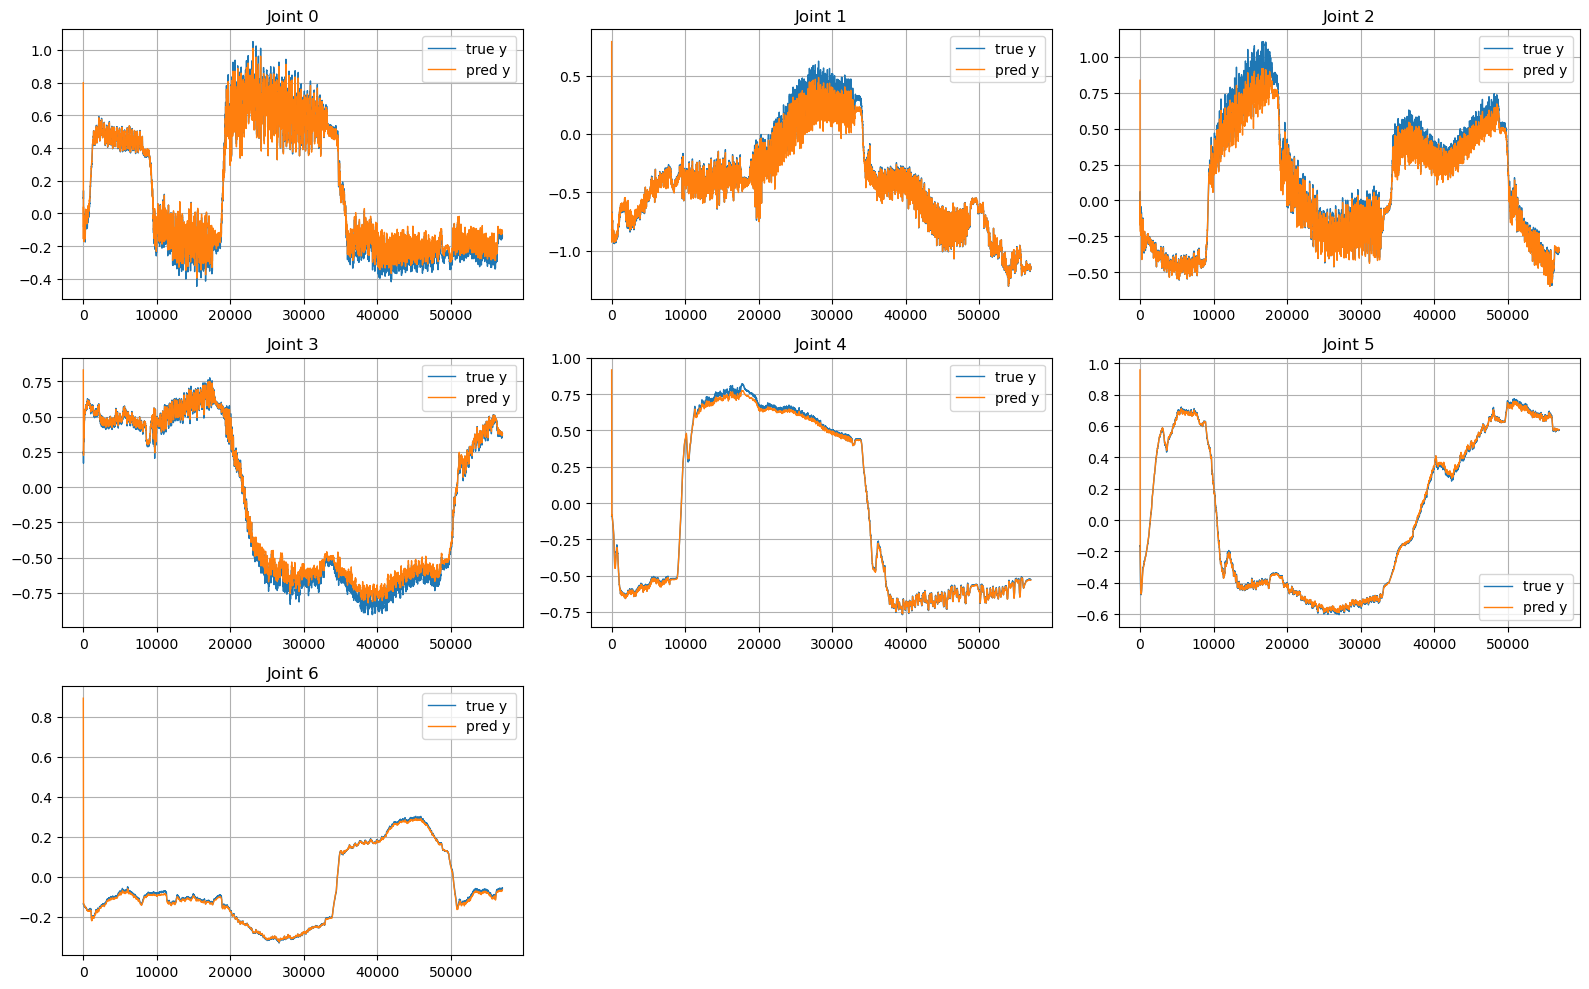

In [9]:
def build_k_rbf_full(xy_ini_full, X_sub, X_col_norm2, gamma_rbf):
    """
    Compute RBF k-vector: k_i = exp(-gamma * ||x_i - xy_ini_full||^2)
    where columns of X_sub are x_i.
    """
    term_xy = float(xy_ini_full @ xy_ini_full) # scalar
    term_ax = X_sub.T @ xy_ini_full # (Hc_sub,)
    d2 = X_col_norm2 + term_xy - 2.0 * term_ax # (Hc_sub,)
    return np.exp(-gamma_rbf * d2).reshape(-1) # (Hc_sub,)

num_joints = 7

plt.figure(figsize=(16, 10))

for j in range(num_joints):
    # Validation data for this joint
    u_test = u_data_valid_full[:, j]
    y_test = y_data_valid_full[:, j]
    T_test = u_test.shape[0]

    # Per-joint kernel / Hankel data
    X_sub = kernel_per_joint[j]["X_sub"] # (d_full, Hc_sub)
    Hy_future_sub = kernel_per_joint[j]["Hy_future_sub"] # (p*T_future, Hc_sub)
    Kg = kernel_per_joint[j]["Kg"] # (Hc_sub, Hc_sub)

    Hc = X_sub.shape[1]
    d_full = X_sub.shape[0]

    # Precompute norms for RBF
    X_col_norm2 = np.sum(X_sub**2, axis=0)

    # A = lambda_g * I + lambda_k * Kg^T Kg
    A = (lambda_g * np.eye(Hc) + lambda_k * (Kg.T @ Kg))

    w = np.linalg.eigvalsh(A)   # symmetric eigenvalue solver
    print("min eigenvalue of A:", w.min())

    A_factor = cho_factor(A, lower=True, check_finite=False)

    # Predictions for this joint
    y_pred = np.zeros_like(y_test)

    m = 1
    p = 1

    # Initialize buffers for u_ini and y_ini
    u_buffer = np.zeros(T_past) # starts all zeros
    y_buffer = np.ones(T_past) # starts all ones

    for k in range(T_test):

        # Build u_ini = last T_past elements of the buffer
        u_ini = u_buffer.reshape(-1)
        y_ini = y_buffer.reshape(-1)

        # Current measured input
        u_cur = u_test[k]
        u_ref = np.tile(u_cur, T_future) # future input
        
        # Build regressor vector [u_ini ; y_ini ; u_future]
        xy_ini_full = np.hstack([u_ini, y_ini, u_ref])

        # RBF vector
        k_vec = build_k_rbf_full(xy_ini_full, X_sub, X_col_norm2, best_gamma_rbf)

        # Closed-form g*
        rhs = lambda_k * (Kg.T @ k_vec)
        g_star = cho_solve(A_factor, rhs, check_finite=False)

        # Predict next friction
        y_future_pred = Hy_future_sub @ g_star
        y_pred[k] = y_future_pred[0]

        # Update buffers
        # shift left and append new real values
        u_buffer = np.roll(u_buffer, -1)
        y_buffer = np.roll(y_buffer, -1)
        u_buffer[-1] = u_test[k] # real measured input
        y_buffer[-1] = y_test[k] # real measured friction

    # Metrics
    mse = np.mean((y_test - y_pred)**2)
    std_true = np.std(y_test)
    std_pred = np.std(y_pred)
    corr = np.corrcoef(y_test, y_pred)[0, 1] if std_true > 0 and std_pred > 0 else np.nan

    print(f"MSE: {mse:.4e}")
    print(f"std(true): {std_true:.4e}")
    print(f"std(pred): {std_pred:.4e}")
    print(f"corr: {corr:.3f}")

    # Plot
    plt.subplot(3, 3, j+1)
    t = np.arange(T_test)
    plt.plot(t, y_test, label="true y", linewidth=1)
    plt.plot(t, y_pred, label="pred y", linewidth=1)
    plt.title(f"Joint {j}")
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()



**Store all relevant objects for C++ controller++**

In [ ]:
def save_matrix_bin(path, M):
    """Save matrix in raw binary row-major format."""
    M = np.asarray(M, dtype=np.float64)
    M.tofile(path)
    return {"rows": M.shape[0], "cols": M.shape[1]}

# main bundle directory
bundle_root = "kernel_deepc_bundle"
os.makedirs(bundle_root, exist_ok=True)

for j in range(7):
    # extract per-joint objects
    X_sub = kernel_per_joint[j]["X_sub"]
    Hy_future_sub = kernel_per_joint[j]["Hy_future_sub"]
    Kg = kernel_per_joint[j]["Kg"]
    Hc_sub = kernel_per_joint[j]["Hc_sub"]

    # create joint folder
    joint_dir = os.path.join(bundle_root, f"joint_{j}")
    os.makedirs(joint_dir, exist_ok=True)

    # store matrices
    meta = {}
    meta["Kg"] = save_matrix_bin(f"{joint_dir}/Kg.bin", Kg)
    meta["X"] = save_matrix_bin(f"{joint_dir}/X.bin", X_sub)
    meta["Hy_future"] = save_matrix_bin(f"{joint_dir}/Hy_future.bin", Hy_future_sub)

    # store scalars
    meta["rbf_scale"] = float(best_gamma_rbf)
    meta["lambda_g"] = float(lambda_g)
    meta["lambda_k"] = float(lambda_k)
    meta["T_past"] = int(T_past)
    meta["T_future"] = int(T_future)

    # JSON metadata
    with open(f"{joint_dir}/meta.json", "w") as f:
        json.dump(meta, f, indent=2)

print("All joint bundles written to:")
print(os.listdir(bundle_root))


All joint bundles written to:
['joint_0', 'joint_3', 'joint_4', 'joint_1', 'joint_5', 'joint_6', 'joint_2']
